## Object Oriented Programming

### Objects.

Object - A 'bundle' of related attributes (variables) and methods (functions).  
One needs a class to create many objects.

Class - Blueprint used to design the layout and structure of an object.

In [1]:
class Car:
    def __init__(self, model, year, color, for_sale):
        self.model = model
        self.year = year
        self.color = color
        self.for_sale = for_sale
    
    def drive(self):
        print(f'You drive the {self.model}')
    
    def stop(self):
        print(f'You stop the {self.model}')

    def describe(self):
        print(f'{self.year} {self.color} {self.model}')

In [2]:
car1 = Car('BMW', 2025, 'Black', False)
print(car1.model)
print(car1.year)
print(car1.color)
print(car1.for_sale)

BMW
2025
Black
False


In [3]:
car2 = Car('Benz', 2023, 'Black', True)

In [4]:
car1.drive()
car2.stop()

You drive the BMW
You stop the Benz


In [5]:
car1.describe()

2025 Black BMW


### Class Variables.

Class variables - Shared among all instances of a class.  
                  Defined outside the constructor.  
                  Allows one to share data across all objects created from that class.

In [6]:
class Student:

    class_year = 2025 # The class variable defined outside the constructor below.

    num_students = 0

    def __init__(self, name, age):
        self.name = name
        self.age = age
        Student.num_students += 1 # Increase the number of students by 1 for every instance created.
        # Use class name in place of self when modifying a class variable.

In [7]:
student1 = Student('Spongebob', 25)
student2 = Student('Patrick', 27)

print(student1.name)
print(student1.age)
print(Student.class_year) # Accessed directly from the class rather than class instance # Good practice.

print(Student.num_students)

Spongebob
25
2025
2


In [8]:
# Creating a third student object to see if student number will increase.
student3 = Student('Squidward', 37)
student4 = Student('Sandy', 28)

print(f'The graduating class of {Student.class_year} has {Student.num_students} students')

The graduating class of 2025 has 4 students


### Inheritance.

Inheritance - Allows a class to inherit attributes and methods from another class.  
              Helps with code reusability and Extensibility.  
              class Child(Parent)

In [9]:
class Animal:
    def __init__(self, name):
        self.name = name
        self.is_alive = True

    def eat(self):
        print(f'{self.name} is eating')

    def sleep(self):
        print(f'{self.name} is sleeping')

In [10]:
class Cat(Animal):
    def speak(self):
        print('Meow')

class Dog(Animal):
    def speak(self):
        print('Woof')

class Mouse(Animal):
    def speak(self):
        print('I saw him do it')

In [11]:
cat = Cat('Tom')
dog = Dog('Scooby')
mouse = Mouse('Jerry')

print(cat.name)
print(cat.is_alive)
cat.eat()
cat.sleep()
cat.speak()

Tom
True
Tom is eating
Tom is sleeping
Meow


### Multiple & Multilevel Inheritance.

Multiple Inheritance - When a child class inherits from more than one parent class C(A, B).

Multilevel Inheritance - When a child class inherits froma parent class which inherits from another parent class.
                         C(B) <- B(A) <- A.

In [12]:
class Animal:

    def __init__(self, name):
        self.name = name

    def eat(self):
        print(f'{self.name} is eating')
    
    def sleep(self):
        print(f'{self.name} is sleeping')

class Prey(Animal):
    def flee(self):
        print(f'{self.name} is fleeing')

class Predator(Animal):
    def hunt(self):
        print(f'{self.name} is hunting')

class Rabbit(Prey):
    pass

class Hawk(Predator):
    pass

class Fish(Prey, Predator): # Multiple Inheritance from both Prey and Predator classes.
    pass

In [13]:
rabbit = Rabbit('Bugs')
hawk = Hawk('Tony')
fish = Fish('Dory')

rabbit.flee()
hawk.hunt()

Bugs is fleeing
Tony is hunting


In [14]:
# Fish inherited methods from both parent classes.
fish.flee()
fish.hunt()

Dory is fleeing
Dory is hunting


In [15]:
# Multilevel Inheritance; C(Prey, Predator) <- B(Animal)
rabbit.eat()
hawk.sleep()
fish.eat()

Bugs is eating
Tony is sleeping
Dory is eating


### Abstract Classes.

Abstract class - A class that cannot be instantiated on its own and is meant to be subclassed.  
                 Contain Abstract methods, which are declared but have no implementation.  
                 Abstract classes:  
                 1. Prevent instantiation of the class itself.  
                 2. Require children to use inherited abstract methods.

In [16]:
from abc import ABC, abstractmethod

class Vehicle(ABC):
    
    @abstractmethod
    def go(self):
        pass

    @abstractmethod
    def stop(self):
        pass

# vehicle = Vehicle() # Can't create an instance of an abstract class

class Car(Vehicle):
# Child class inherits abstract methods
    def go(self):
        print('You drive the car')
    
    def stop(self):
        print('You stop the car')

car = Car()

car.go()
car.stop()

class Motorcycle(Vehicle):

    def go(self):
        print('You ride the Motorcycle')
    
    def stop(self):
        print('You stop the Motorcycle')

motorcycle = Motorcycle()

motorcycle.go()
motorcycle.stop()

class Boat(Vehicle):

    def go(self):
        print('You sail the boat')
    
    def stop(self):
        print('You anchor the boat')

boat = Boat()

boat.go()
boat.stop()

You drive the car
You stop the car
You ride the Motorcycle
You stop the Motorcycle
You sail the boat
You anchor the boat


### Super()

Super() - Function used in a child class to call methods from a parent class (Superclass).
          Allows one to extend the functionality of inherited methods.

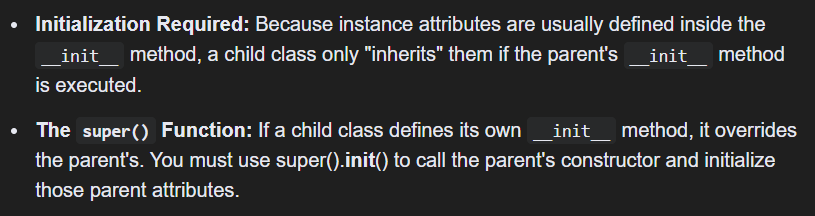

In [8]:
class Shape:
    def __init__(self, color, is_filled):
        self.color = color
        self.is_filled = is_filled

    def describe(self):
        print(f'It is {self.color} and {'filled' if self.is_filled else 'not_filled'}')

class Circle(Shape):
    def __init__(self, color, radius, is_filled):
        super().__init__(color, is_filled)
        self.radius = radius
    
    def describe(self):
        super().describe()
        print(f'It is a circle with an area of {3.14 * (self.radius ** 2)} cm^2')

class Square(Shape):
    def __init__(self, color, length, is_filled):
        super().__init__(color, is_filled)
        self.length = length
    
    def describe(self):
        super().describe()
        print(f'It is a square with an area of {self.length * self.length} cm^2')


class Triangle(Shape):
    def __init__(self, color, width, height, is_filled):
        super().__init__(color, is_filled)
        self.width = width
        self.height = height

    def describe(self):
        super().describe()
        print(f'It is a triangle with an area of {(self.width * self.height / 2)} cm^2')

In [9]:
circle = Circle(color = 'Blue', radius = 13, is_filled = 'False')
print(circle.radius)

square  = Square('Yellow', 5, True)
print(square.is_filled)

triangle = Triangle('red', 3, 5, True)
print(triangle.color)

13
True
red


In [ ]:
circle.describe()
square.describe()
triangle.describe()

It is Blue and filled
It is a circle with an area of 530.66 cm^2
It is Yellow and filled
It is a square with an area of 25 cm^2
It is red and filled
It is a triangle with an area of 7.5 cm^2


### PolyMorphism.

Polymorphism - Greek word that means to have many forms.
               Poly - Many.
               Morphe - Form.

Two ways to achieve polymorphism:
1. Inheritance - An object could be treated of the same type as the parent class.
2. Duck Typing - An object must have the necessary attributes/methods.

In [56]:
class Shape:
    
    @abstractmethod
    def area(self):
        pass

class Circle(Shape):
    def __init__(self, radius):
        self.radius = radius
    
    def area(self):
        return 3.14 * self.radius **2

class Square(Shape):
    def __init__(self, length):
        self.length = length

    def area(self):
        return self.length * self.length

class Triangle(Shape):
    def __init__(self, base, height):
        self.base = base
        self.height = height

    def area(self):
        return self.base * self.height / 2

class Pizza(Circle): # Is a pizza, Is a circle, and is a shape. It has many forms. Thus polymorphism.
    def __init__(self, topping, radius):
        super().__init__(radius)
        self.topping = topping

shapes = [Circle(3), Square(5), Triangle(4, 2), Pizza('Pepperoni', 15)]

for shape in shapes:
    print(f'The area is {shape.area()} cm^2')

The area is 28.26 cm^2
The area is 25 cm^2
The area is 4.0 cm^2
The area is 706.5 cm^2


### Duck Typing.

Duck Typing - Another way to achieve polymorphism besides inheritance.
              Object must have the minimum necessary attributes/methods.
              'If it looks like a duck and quacks like a duck, it must be a duck'.

In [63]:
class Animal:

    alive = True

class Dog(Animal):
    def speak(self):
        print('Woof!')

class Cat(Animal):
    def speak(self):
        print('Meow')

class Car():

    alive = True

    def speak (self):
        print('Honk')

animals = [Dog(), Cat(), Car()]

for animal in animals:
    animal.speak()
    print(animal.alive)

Woof!
True
Meow
True
Honk
True


### Aggregation.

Aggregation - Represents a relationship where one object(The whole) contains references to one or more independent objects(The parts).

In [16]:
class Library:
    def __init__(self, name):
        self.name = name
        self.books = []

    def add_books(self, book):
        self.books.append(book)

    def list_books(self):
        # return [(book.title, book.author) for book in self.books]
        return [f'{book.title} by {book.author}' for book in self.books]

class Book:
    def __init__(self, title, author):
        self.title = title
        self.author = author

library = Library("J.K Memorial Library")

book1 = Book('Gifted Hands', 'Ben Carson')
book2 = Book('The Hobbit', 'J.K.K Tolkien')
book3 = Book('The color of Magic', 'Terry Pratchet')

library.add_books(book1)
library.add_books(book2)
library.add_books(book3)

print(library.name)
print(library.list_books())

J.K Memorial Library
['Gifted Hands by Ben Carson', 'The Hobbit by J.K.K Tolkien', 'The color of Magic by Terry Pratchet']


### Composition.

Composition - The composed object directly owns its components, which cannot exist independently.

In [19]:
class Engine:
    def __init__(self, horsepower):
        self.horsepower = horsepower

class Wheel:
    def __init__(self, size):
        self.size = size

class Car:
    def __init__(self, make, model, horsepower, wheel_size):
        self.make = make
        self.model = model
        self.engine = Engine(horsepower)
        self.wheels = [Wheel(wheel_size) for wheel in range(4)]
    
    def car_display(self):
        return f'{self.make} {self.model}, {self.engine.horsepower}hp, {self.wheels[0].size}in'

car1 = Car('Nissan GTR', 'R35', 595, 21)

car1.car_display()

'Nissan GTR R35, 595hp, 21in'

### Nested Class.

Nested Class - A class defined within another class.
               class Outer:
                    class inner:
            
Benefits - Allows one to logically group classes that are closely related.  
           Encapsulates private details that aren't relevant outside of the outer class.  
           Keeps the namespace clean, reduces the possibility of naming conflicts.

In [15]:
class Company:
    class Employee:
        def __init__(self, name, position):
            self.name = name
            self.position = position

        def get_details(self):
            return f'{self.name} {self.position}'

    def __init__(self, company_name):
        self.company_name = company_name
        self.employee = []

    def add_employee(self, name, position):
        new_employee = self.Employee(name, position)
        return self.employee.append(new_employee)

    def list_employees(self):
        # return [(employee.name, employee.position) for employee in self.employee]
        # return [f'{employee.name}, {employee.position}' for employee in self.employee]
        return [employee.get_details() for employee in self.employee]

company1 = Company('The Krusty Krab')

print(company1.company_name)

company1.add_employee('Eugene', 'Manager')
company1.add_employee('Spongebob', 'Chef')
company1.add_employee('Squidward', 'Cashier')

print(company1.list_employees())

company2 = Company('The Chum Bucket')

company2.add_employee('Sheldon', 'Manager')
company2.add_employee('Karen', 'Assistant')

for employee in company2.list_employees():
    print(employee)

The Krusty Krab
['Eugene Manager', 'Spongebob Chef', 'Squidward Cashier']
Sheldon Manager
Karen Assistant


### Static Methods.

Static Method - A method that belongs to a class rather than any object from that class (instance).
                Usually used for general utility functions.

Instance methods - Best for operations on instances of the class (objects).  
Static methods - Best for utility functions that do not need access to class data.